In [ ]:
# Execute first
import os
FIG_ROOT = os.environ.get('SCDIS_FIG', os.path.join(os.environ['SCDIS_ROOT'], 'figures'))

In [1]:
import numpy as np
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from sklearn.metrics import r2_score
import os
import gc
from tqdm import tqdm

from scdisentangle.train.CustomIterations import CustomIterations

In [2]:
import matplotlib
matplotlib.rcParams['svg.fonttype'] = 'none'
matplotlib.rcParams['font.family'] = 'Liberation Sans'
matplotlib.rcParams['mathtext.default'] = 'regular'
matplotlib.rcParams['axes.unicode_minus'] = False

In [3]:
def plot_scatter(pert_combo, n_degs=20, save_path=None, filter_annot=None):
    
    pert1, pert2 = pert_combo.split('+')
    pert_combo_renamed = pert_combo.replace('+', '_')
    # Read observed data
    adata_org = sc.read_h5ad('../../Datasets/preprocessed_datasets/norman.h5ad')
    adata_org.X = adata_org.X.toarray()

    adata = adata_org.copy()

    # Read scDisentangle, CPA and GEARS prediction
    adata_pred_scdis = sc.read_h5ad(
        f'../../Benchmarks/SCDISENTANGLE/Norman/predictions/single_only/{pert_combo}.h5ad'
    )
    adata_pred_cpa = sc.read_h5ad(
        f'../../Benchmarks/CPA/Norman/predictions/single_only/{pert_combo}.h5ad'
    )
    
    adata_pred_gears = sc.read_h5ad(
        f'../../Benchmarks/GEARS/Norman/predictions/single_only/{pert_combo_renamed}.h5ad'
    )
    adata_pred_gears.X = adata_pred_gears.X.toarray()
    
    # Normalize
    sc.pp.normalize_total(adata, target_sum=adata_org.uns['single_perts_median'])
    sc.pp.log1p(adata)

    sc.pp.normalize_total(adata_pred_scdis, target_sum=adata_org.uns['single_perts_median'])
    sc.pp.log1p(adata_pred_scdis)
    
    sc.pp.normalize_total(adata_pred_cpa, target_sum=adata_org.uns['single_perts_median'])
    sc.pp.log1p(adata_pred_cpa)
    
    # GT
    gt_combo = adata[adata.obs['cond_harm']==pert_combo].X.mean(axis=0)
    
    # Predictions
    pred_scdis = adata_pred_scdis[adata_pred_scdis.obs['cond_harm_pred']==pert_combo].X.mean(axis=0)
    pred_cpa = adata_pred_cpa[adata_pred_cpa.obs['cond_harm_pred']==pert_combo].X.mean(axis=0)
    pred_gears = adata_pred_gears[adata_pred_gears.obs['cond_harm_pred']==pert_combo].X.mean(axis=0)

    calibration_avg = CustomIterations().calibrate_predictions(
        adata_pred=adata_pred_scdis,
        adata_gt=adata,
        cond_key='cond_harm',
        target_perturbation=pert_combo
    )
    calibrated_X = pred_scdis + calibration_avg
    pred_scdis = calibrated_X

    degs_combo = adata_org.uns['rank_genes_groups'][pert_combo].tolist()[:n_degs]
    degs_p1 = adata_org.uns['rank_genes_groups'][pert1].tolist()[:n_degs]
    degs_p2 = adata_org.uns['rank_genes_groups'][pert2].tolist()[:n_degs]

    degs_idx = [adata_org.var_names.get_loc(x) for x in degs_combo]

    # Create colors & legends for shared or specific
    colors = []
    labels_legend = []
    for g in degs_combo:
        in_p1 = g in degs_p1
        in_p2 = g in degs_p2

        if in_p1 and in_p2:
            colors.append('#9467bd')
            labels_legend.append('Shared')
        elif in_p1:
            colors.append('#1f77b4')
            labels_legend.append(f'{pert1}-specific')
        elif in_p2:
            colors.append('#ff7f0e')
            labels_legend.append(f'{pert2}-specific')
        else:
            colors.append('#2ca02c')
            labels_legend.append(f'Combo-specific')

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    for ax, pred, method_name in zip(
        axes,
        [
            pred_scdis[degs_idx],
            pred_cpa[degs_idx],
            pred_gears[degs_idx]
        ],
        ['scDisentangle', 'CPA', 'GEARS']
        ):
        gt_vals = gt_combo[degs_idx]
        r2 = r2_score(gt_vals, pred) * 100
        ax.scatter(gt_vals, pred, c=colors, s=80, edgecolors='k', linewidths=0.5, zorder=3)

        for i, g in enumerate(degs_combo):
            if filter_annot is None:
                ax.annotate(g, (gt_vals[i], pred[i]), fontsize=6, alpha=0.7,
                        xytext=(3, 3), textcoords='offset points')
            else:
                if g in filter_annot:
                    ax.annotate(g, (gt_vals[i], pred[i]), fontsize=6, alpha=0.7,
                        xytext=(3, 3), textcoords='offset points')

        # diagonal
        lims = [min(gt_vals.min(), pred.min()) - 0.1, max(gt_vals.max(), pred.max()) + 0.1]
        ax.plot(lims, lims, 'k--', alpha=0.3, zorder=1)
        ax.set_xlim(lims); ax.set_ylim(lims)
        ax.set_xlabel('Ground truth mean expression')
        ax.set_ylabel('Predicted mean expression')
        ax.set_title(f'{method_name}\nR² = {r2:.1f}%')
        ax.set_aspect('equal')

    legend_elements = [
        Patch(facecolor='#1f77b4', label=f'{pert1}-specific DEG'),
        Patch(facecolor='#ff7f0e', label=f'{pert2}-specific DEG'),
        Patch(facecolor='#9467bd', label='Shared DEG'),
        Patch(facecolor='#2ca02c', label='Combo-specific DEG'),
    ]
    fig.legend(handles=legend_elements, loc='lower center', ncol=4, bbox_to_anchor=(0.5, -0.05))
    fig.suptitle(f'{pert_combo} Top {n_degs} DEGs (single_only)', fontsize=14, y=1.02)

    if save_path is not None:
        plt.savefig(f'{save_path}/{pert_combo}_{n_degs}.svg', dpi=600)
    
    del adata_org, adata, adata_pred_scdis, adata_pred_cpa, adata_pred_gears
    gc.collect()

In [4]:
single_only_perts = [
        'CBL+CNN1', 'DUSP9+ETS2', 'DUSP9+MAPK1', 
        'ETS2+MAPK1', 'ETS2+CEBPE', 'CNN1+MAPK1', 
        'CEBPB+CEBPA', 'CBL+PTPN12', 'AHR+FEV', 
    ]

In [5]:
save_path = f'{FIG_ROOT}/Norman/scatter'
os.makedirs(save_path, exist_ok=True)

  0%|                                                                                                                                                                                                                                                     | 0/9 [00:00<?, ?it/s]/home/SE/miniconda3/envs/trials/lib/python3.10/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/SE/miniconda3/envs/trials/lib/python3.10/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
adata.X seems to be already log-transformed.
 11%|██████████████████████████▎                                                                                                                                                                                                   

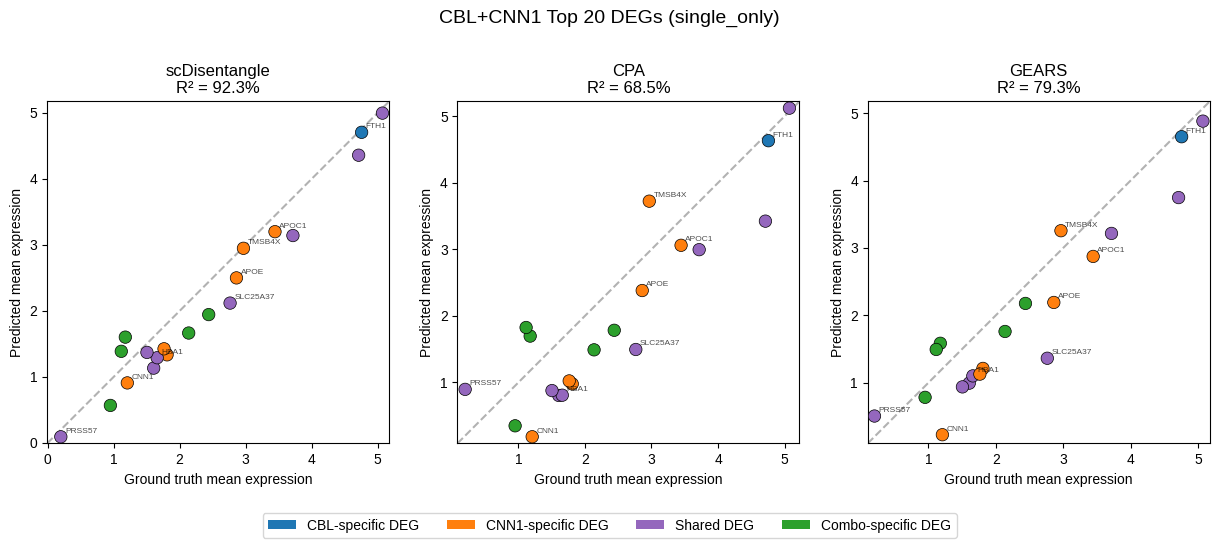

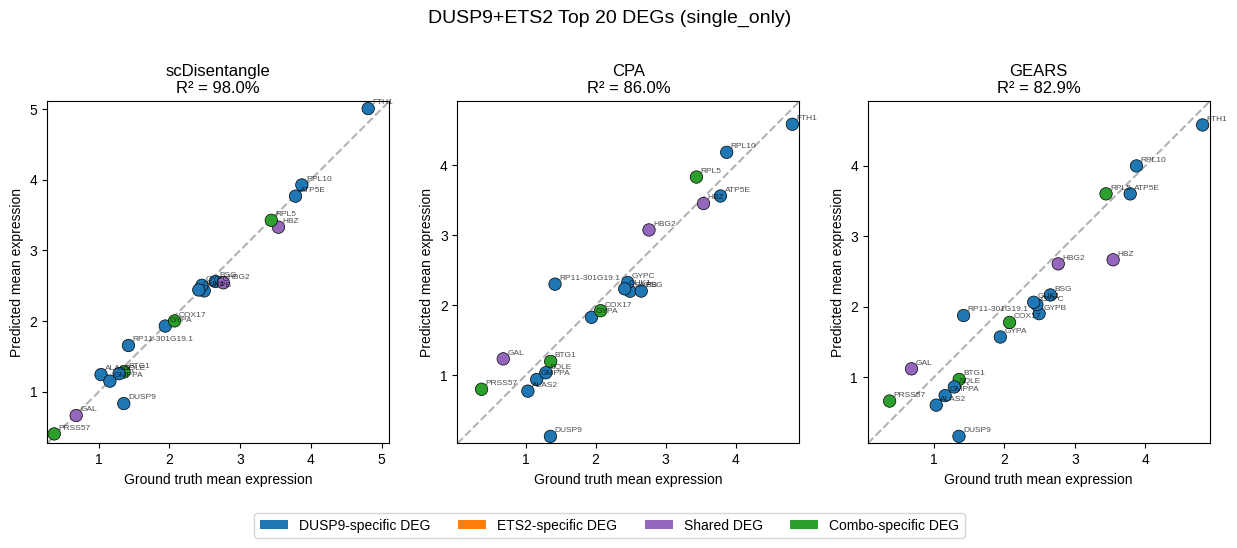

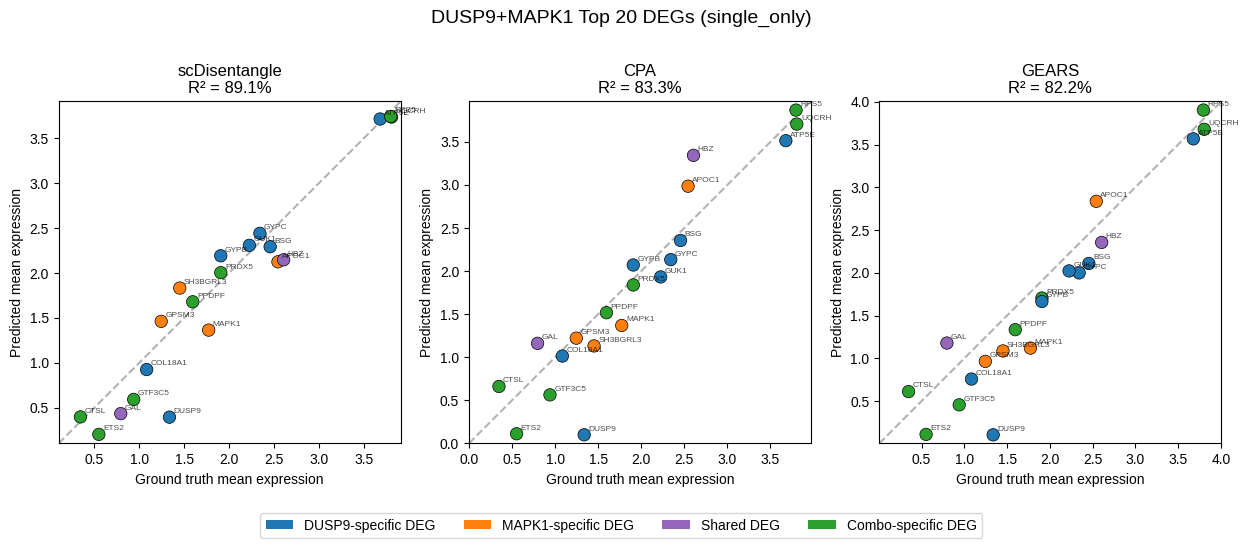

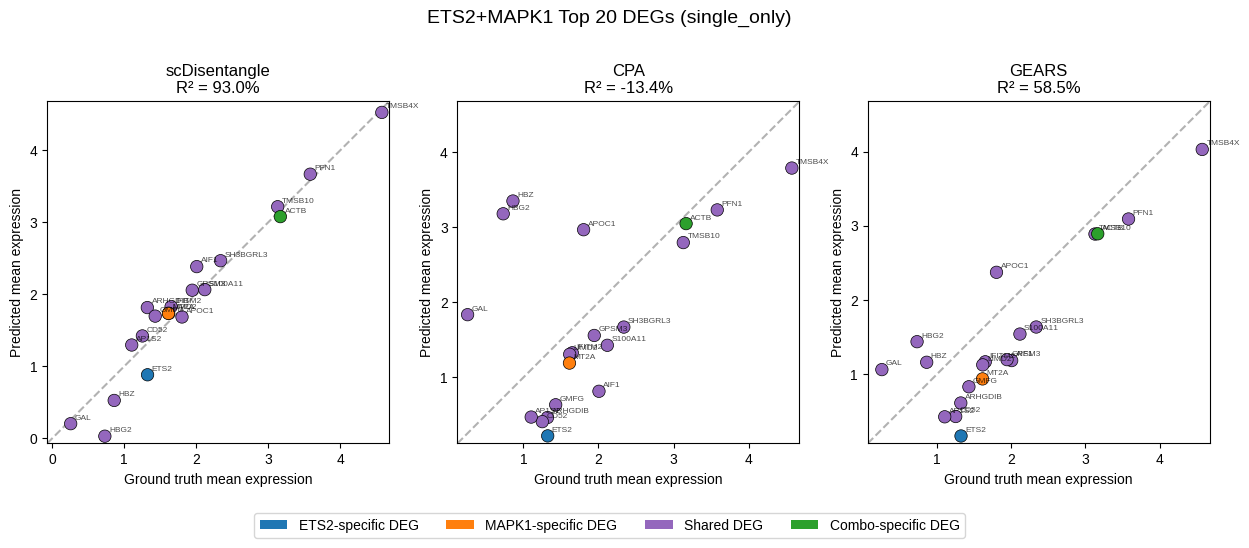

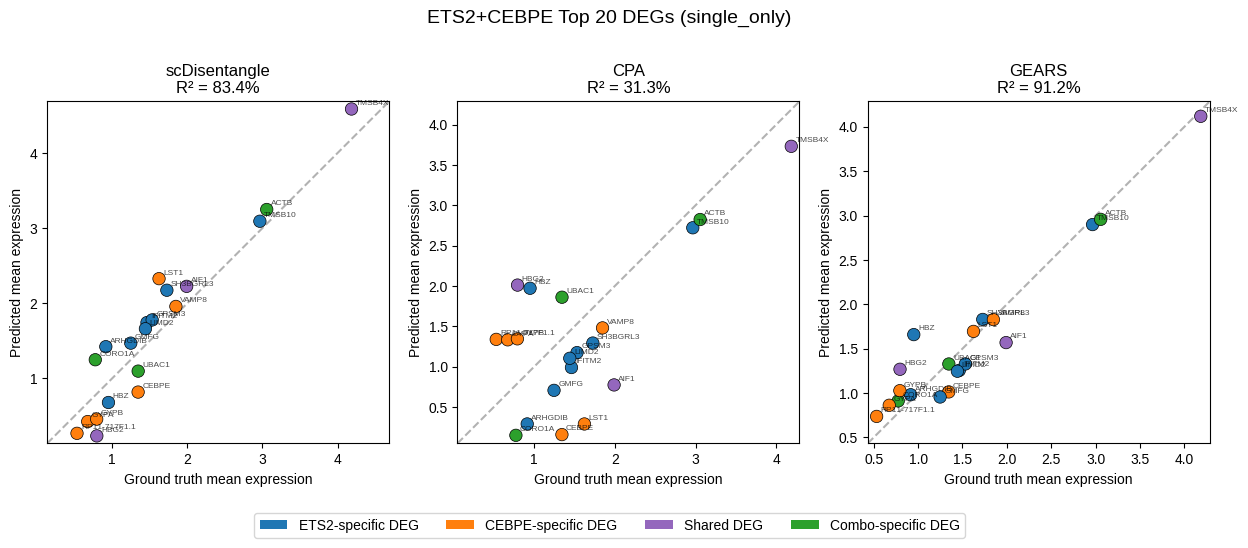

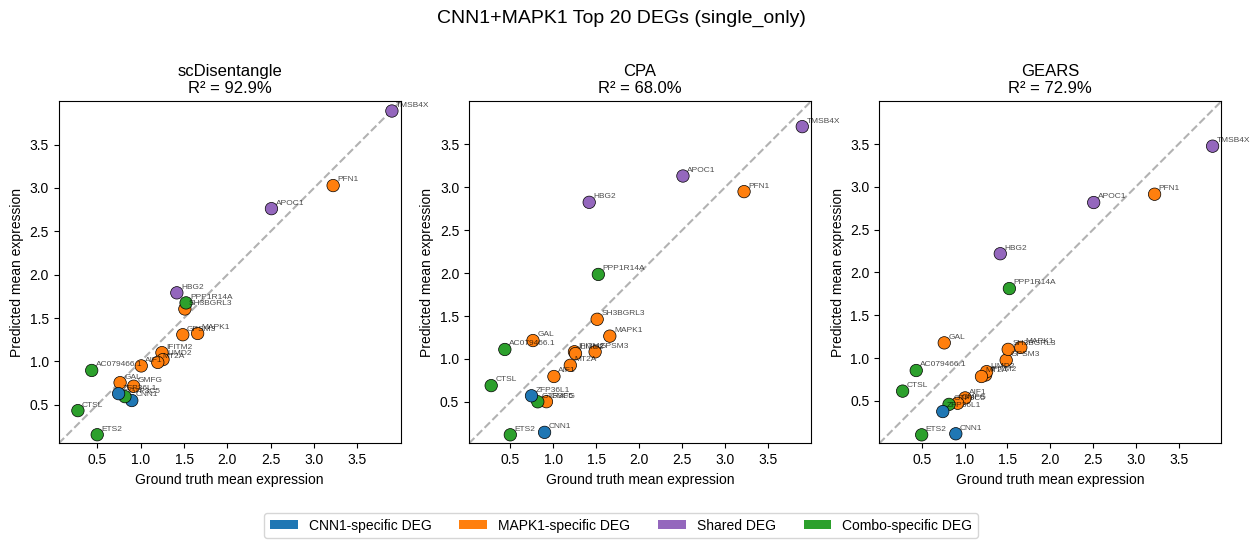

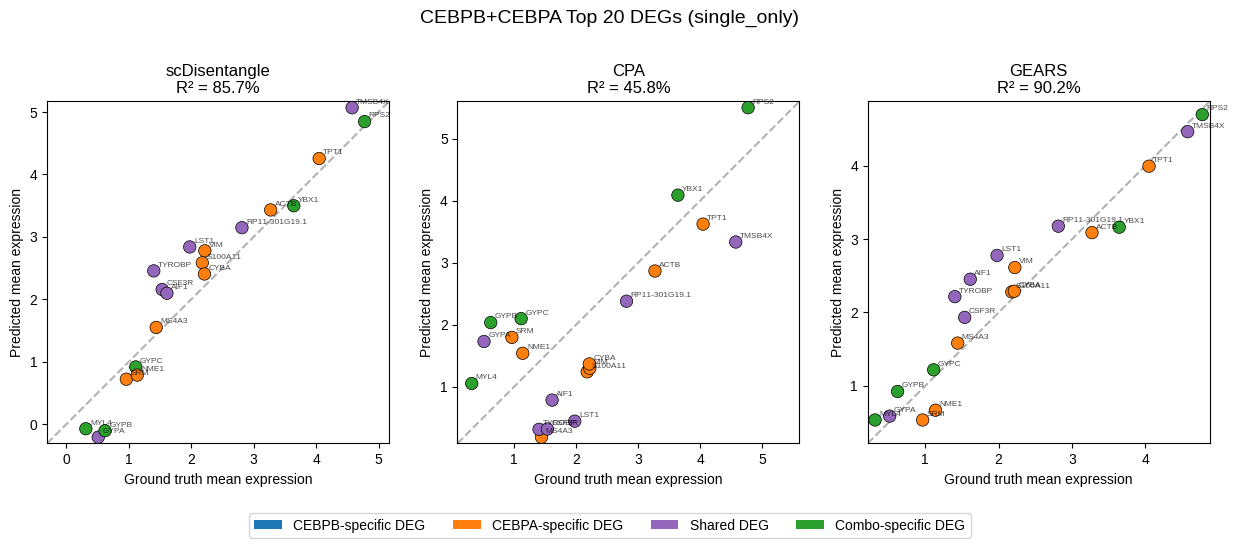

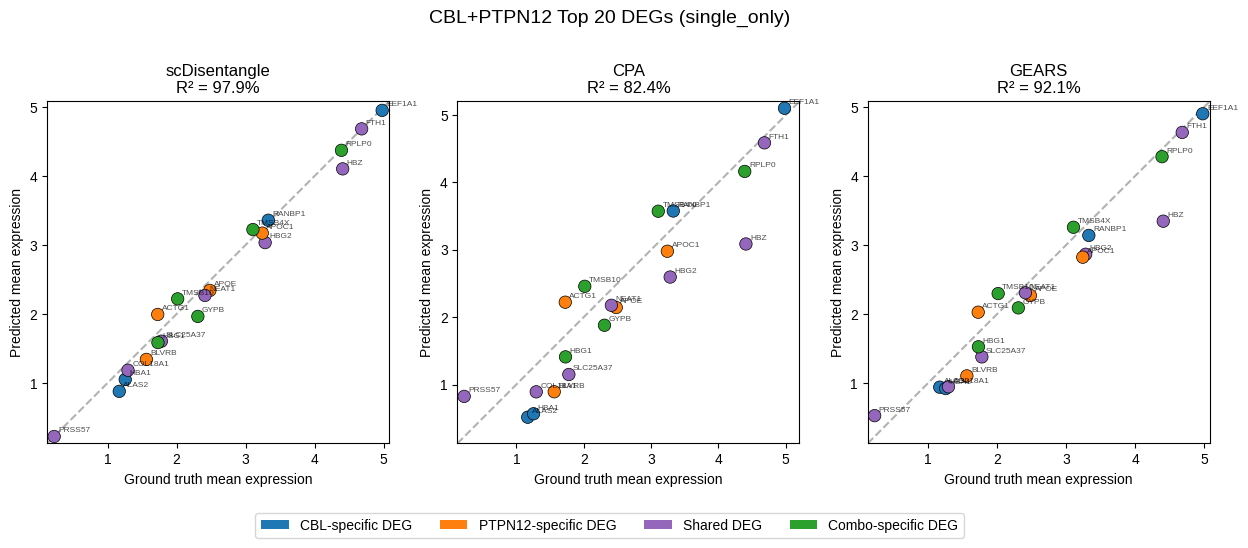

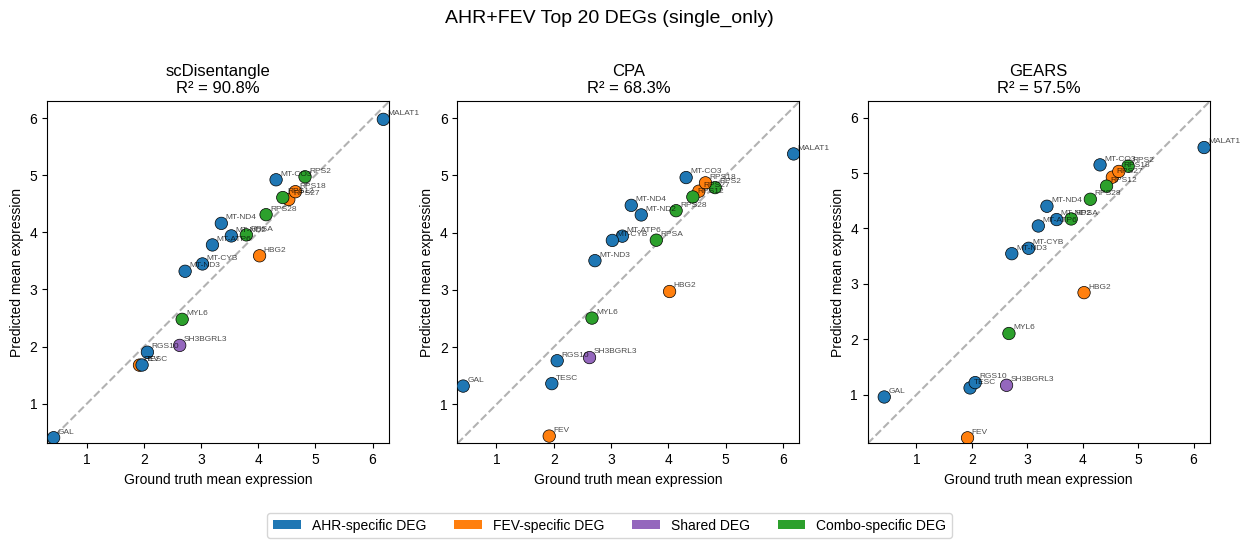

In [6]:
for pert_combo in tqdm(single_only_perts):
    if pert_combo == 'CBL+CNN1':
        filter_annot = ['CNN1', 'FTH1', 'APOC1', 'APOE', 'HBA1', 'TMSB4X', 'PRSS57', 'SLC25A37']
    else:
        filter_annot = None
    plot_scatter(pert_combo, save_path=save_path, filter_annot=filter_annot)